In [1]:
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import torch
import time
import seaborn as sns
from sklearn.metrics.pairwise import linear_kernel
from scipy.linalg import svd

from sklearn.metrics.pairwise import linear_kernel

sys.path.insert(0,os.path.abspath('/notebooks/3902_nodespec'))
sys.path.insert(0,os.path.abspath('/notebooks/pytorchtimseries'))
from tqdm.notebook import tqdm



In [2]:
from src.datasets.SimFreqCF import SimFreqCF
# from src.utils.sigma import wv_sigma
dataset_path = "../data/"

sim3f = SimFreqCF(root=dataset_path)

[0.52359878 0.52323248 0.52286669 ... 0.0654613  0.06545557 0.06544985]
[(12, 96)]


In [3]:
sim3f.w, sim3f.wt

(array([0.52359878, 0.52323248, 0.52286669, ..., 0.0654613 , 0.06545557,
        0.06544985]),
 array([0.00000000e+00, 5.23232476e-01, 1.04573338e+00, ...,
        6.54416654e+02, 6.54424838e+02, 6.54433020e+02]))

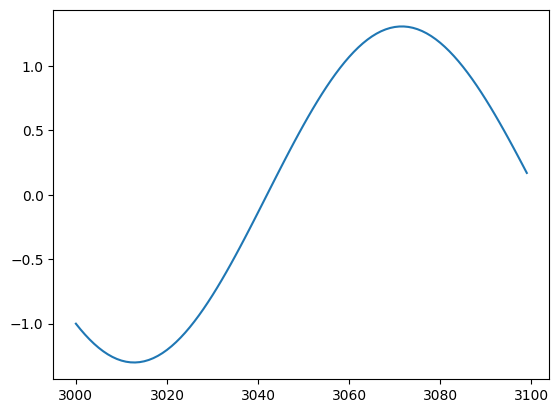

In [13]:
data = sim3f.df.iloc[:, 0]
signal = data[3000:3100]
plt.plot(signal)
# plt.plot(data)

In [4]:
sim3f.t
sim3f.w

array([0.52359878, 0.52323248, 0.52286669, ..., 0.0654613 , 0.06545557,
       0.06544985])

In [18]:
T

array([12.        , 12.00840084, 12.01680168, ..., 95.98319832,
       95.99159916, 96.        ])

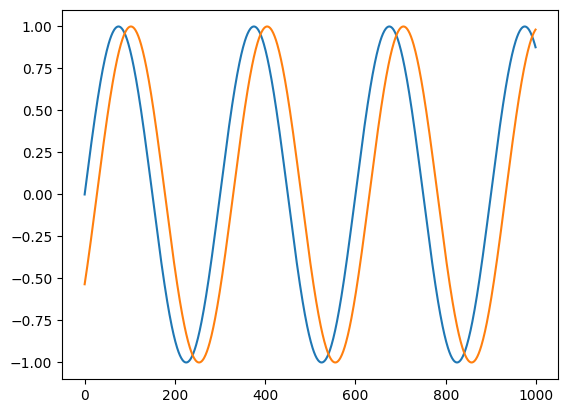

In [27]:
t = np.arange(10000)
T = np.linspace(300, 400, 10000)
plt.plot(np.sin(2*np.pi/300*t)[-1000:])
plt.plot(np.sin(2*np.pi/T*t)[-1000:])

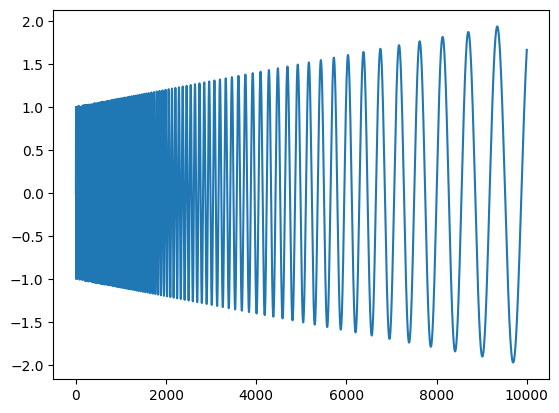

In [5]:
data = sim3f.df.iloc[:, 0]
signal = data[-1000:]
plt.plot(data)
# plt.plot(data)

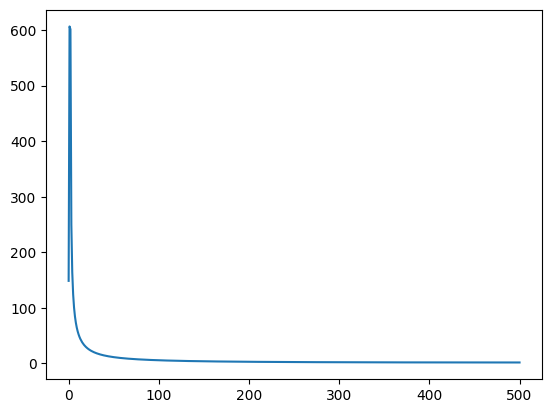

In [6]:
signal_fft = torch.fft.rfft(torch.tensor(signal.values))
plt.plot(torch.arange(len(abs(signal_fft))), abs(signal_fft))

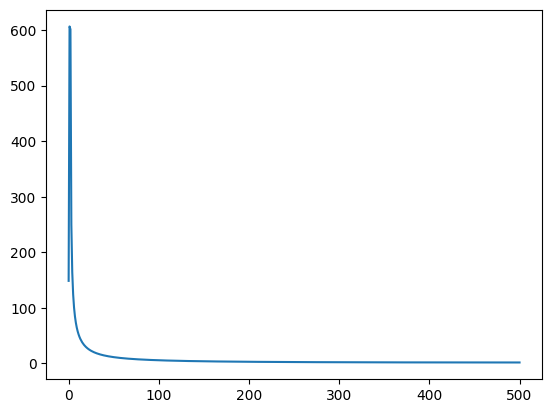

In [7]:
signal_tensor = torch.tensor(signal.values)
signal_fft = torch.fft.rfft(signal_tensor)
plt.plot(torch.arange(len(abs(signal_fft))), abs(signal_fft))

In [83]:
sftf = torch.stft(
    signal_tensor, 
    100,
    center=False,
    hop_length=100,
    return_complex=True,
    onesided=True
)

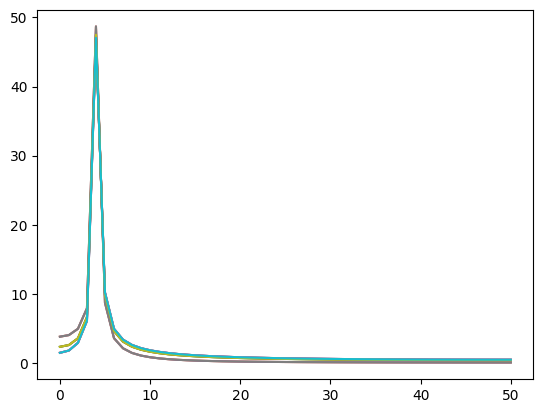

In [84]:
plt.plot(abs(sftf))


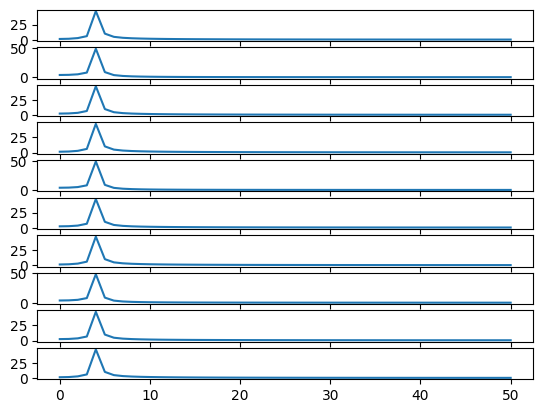

In [85]:
fig, axes = plt.subplots(sftf.shape[1])
for i in range(sftf.shape[1]):
    axes[i].plot(abs(sftf[:, i]))
# fig

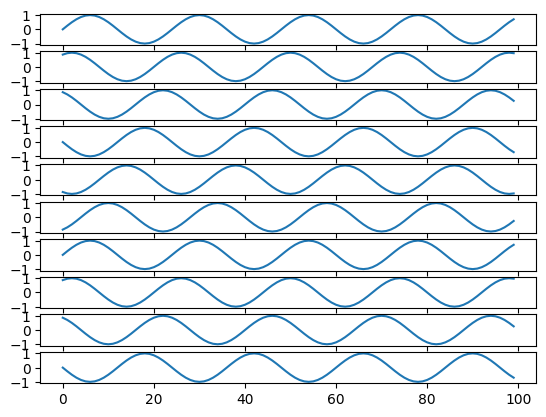

In [86]:
fig, axes = plt.subplots(sftf.shape[1])
for i in range(sftf.shape[1]):
    axes[i].plot(torch.fft.irfft(sftf[:, i]))
# fig